# Predicting Motor Skill Classification from Interpersonal Coordination Dynamics

This notebook develops a binary classifier to distinguish children with **Typical Motor Skills (TMS)** from those with **Lower Motor Skills (LMS)** based on interpersonal coordination dynamics during rhythmic tapping tasks.

## Overview

1. **Data Preparation**: Load participant data and define binary classification target using MABC (Green = 0 vs. Amber/Red = 1).
2. **Model Training**: Provides options to train a linear (L2-regularised logistic regression) and nonlinear (Histogram-based Gradient Boosting Classifier) classifier. Both options use Leave-One-Out cross-validation (LOO-CV) for unbiased performance estimation on small samples.
3. **Visualisation**: Provides a ROC curve with bootstrapped confidence intervals and feature importance visualisation for logistic regression

### 1. Data Preparation

This section imports the relevant libraries and loads and manipulates the data in preparation for modelling. 

In [47]:
# Data Manipulation Libraries
import pandas as pd
import numpy as np
import re

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl

# Machine Learning Libraries
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, 
    roc_curve, auc
)

In [48]:
# Load data
df = pd.read_excel("McQueen_M.Skills_IPS_Data.xlsx", sheet_name="Sheet1", na_values="-")

# Make a copy to avoid modifying original dataframe
df = df.copy()

# Use MABC to create a binary target variable (0=Green, 1=Amber/Red)
df["mabc_binary"] = df["mabc_interpretation"].map({
    "Green": 0,
    "Amber": 1,
    "Red": 1
})

# Check the number of samples in each class
print("Class counts (0=Green, 1=Amber/Red):")
print(df["mabc_binary"].value_counts(dropna=False))

# Include participants based on MABC-2 classification
include_mask = (
    (df["data_alignment"] == "Aligned") |
    (
        (df["data_alignment"] == "Misaligned") &
        (df["data_violations"].fillna("").str.contains("MABC"))
    )
)

df = df.loc[include_mask].copy()

# Summary of inclusion filter
print("\nInclusion filter summary (Aligned OR Misaligned + MABC):")
print(f"Included rows: {include_mask.sum()} / {len(include_mask)}")
print(f"Excluded rows: {(~include_mask).sum()}")

# OPTIONAL: Remove ppt_exp trials where exp_met coordination was below 0.8
apply_exp_met_cutoff = False # Set to True to run a sensitivity analysis applying this cutoff
exp_met_threshold = 0.8

if apply_exp_met_cutoff:
    # Find all Exp_Met columns that look like B#_T#_Exp_Met
    exp_met_cols = [
        c for c in df.columns
        if re.match(r"^B\d+_T\d+_Exp_Met$", c)
    ]

    # Log which pairs of columns we are removing for transparency
    removed_pairs = []

    # For each Exp_Met column, check if the value is below the threshold (or missing) and if so, set the corresponding Ppt_Exp column to NaN
    for exp_col in exp_met_cols:
        # Find corresponding Ppt_Exp column for the same block/trial
        ppt_exp_col = exp_col.replace("_Exp_Met", "_Ppt_Exp")

        # Only proceed if that Ppt_Exp column exists
        if ppt_exp_col not in df.columns:
            continue

        # Identify rows where experimenter timing failed (or missing)
        fail_mask = df[exp_col].isna() | (pd.to_numeric(df[exp_col], errors="coerce") < exp_met_threshold)

        # Set the corresponding Ppt_Exp value to NaN (i.e., remove that trial)
        n_fail = int(fail_mask.sum())
        if n_fail > 0:
            df.loc[fail_mask, ppt_exp_col] = np.nan
            removed_pairs.append((exp_col, ppt_exp_col, n_fail))

    # Print summary
    print(f"\n[QC] Exp_Met thresholding enabled (threshold={exp_met_threshold}).")
    if len(removed_pairs) == 0:
        print("[QC] No Ppt_Exp trials were removed.")
    else:
        print("[QC] Removed Ppt_Exp values where corresponding Exp_Met < threshold (or missing):")
        for exp_col, ppt_exp_col, n_fail in removed_pairs:
            print(f"  - {ppt_exp_col} removed for {n_fail} rows (based on {exp_col})")

# Set up features (rho values) and target (binary MABC interpretation)

## Coordination features

### Keep only features that involve the participant (i.e., exclude experimenter–metronome coupling)
rho_cols = [
    c for c in df.columns
    if c.startswith("B")
    and "_" in c
    and not c.endswith("_Exp_Met")
]

## Demographic features
df["child_gender"] = df["child_gender"].map({"Male": 0, "Female": 1})
demo_cols = ["child_age_years", "child_gender"]

## Build feature list
feature_cols = rho_cols #+ demo_cols if you want to include demographics as features

## Print the final list of features we are using for transparency
print(f"Total feature columns: {len(feature_cols)}")
print("Feature columns:", feature_cols)

Class counts (0=Green, 1=Amber/Red):
mabc_binary
0.0    83
1.0    43
NaN     2
Name: count, dtype: int64

Inclusion filter summary (Aligned OR Misaligned + MABC):
Included rows: 106 / 128
Excluded rows: 22
Total feature columns: 13
Feature columns: ['B1_T2_Ppt_Met', 'B1_T3_Ppt_Exp', 'B2_T2_Ppt_Met', 'B2_T3_Ppt_Exp', 'B2_T4_Ppt_Exp', 'B3_T1_Ppt_Met', 'B3_T2_Ppt_Met', 'B3_T3_Ppt_Exp', 'B3_T4_Ppt_Exp', 'B4_T1_Ppt_Met', 'B4_T2_Ppt_Met', 'B4_T3_Ppt_Exp', 'B4_T4_Ppt_Exp']


### 2. Model Training

This section trains two models:
- An L2-regularised logistic regression model
    - Pros: Allows us to directly examine which features are associated with green versus amber/red classification.
    - Cons: Requires complete cases (participants with any missing values are excluded). May underperform if relationships between features and outcomes are non-linear.
- A Histogram-based gradient boosting classifier (HGBC)
    - Pros: Retains cases with partial missingness. Captures non-linear relationships. Higher predictive accuracy in small samples.
    - Cons: Does not provide class-specific directionality (i.e., which features specifically drive Green vs Amber/Red).

Both models were evaluated using Leave-One-Out cross-validation (LOO-CV), which provides nearly unbiased performance estimates for small samples. Here, each participant is used once as a held-out test case while the model is trained on all remaining participants.

**Key findings:**
- Logistic regression:
    - Balanced accuracy =  ~70%
    - Amber/Red classification was associated with relatively stronger participant–metronome coordination
    - Green classification was associated with a mix of strong participant–metronome and participant–experimenter coordination
    - This suggests that high performance (Green) may reflect more flexible or context-sensitive coordination, whereas Amber/Red classification may reflect more rigid entrainment to the external pacing signal.
- HGBC:
    - Balanced accuracy = ~77%
    - Top performing features comprise a mix of participant-experimenter and participant-metronome trials.

In [49]:
# Choose model
logReg = False  # set to False to run HGBC instead

# Logistic regression pipeline
if logReg:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",      # good for small datasets
            C=1.0,                   # regularisation strength
            class_weight="balanced", # assigns weights to each observation in the training set - helpful as green:amber/red ratio is ~2:1
            max_iter=5000,
            random_state=42
        ))
    ])

    ## Drop all rows with missing outcome or missing predictors
    model_df = df.dropna(subset=["mabc_binary"] + feature_cols).reset_index(drop=True)

    ## Assign features and target variable
    X = model_df[feature_cols].astype(float)
    y = model_df["mabc_binary"].astype(int)

    ## Print final N after dropping missing rows
    print("\nFinal N after dropping missing rows:", len(model_df))

    ## Check class balance after dropping missing data
    print("\nMABC class counts (after exclusion):")
    print(model_df["mabc_interpretation"].value_counts())

    ## Check binary class balance
    print("\nBinary MABC counts (0=Green, 1=Amber/Red):")
    print(model_df["mabc_binary"].value_counts())

# HistGradientBoostingClassifier pipeline
if not logReg:
    pipe = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.05,
        max_depth=3,
        max_iter=300,
        class_weight="balanced",
        random_state=42
    )

    ## Drop all rows with missing outcome but keep rows with missing predictors
    model_df = df.dropna(subset=["mabc_binary"]).reset_index(drop=True)

    ## Assign features and target variable
    X = model_df[feature_cols]   # leave NaNs in place
    y = model_df["mabc_binary"].astype(int)

# Leave-one-out cross-validated predictions
## Note: Used LOO over k-fold CV due to small sample size.
loo = LeaveOneOut()

# Predicted probabilities for class 1 (Amber/Red)
y_prob = cross_val_predict(pipe, X, y, cv=loo, method="predict_proba")[:, 1]

# Convert to class predictions using 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

# Evaluate model performance
acc = accuracy_score(y, y_pred)
bacc = balanced_accuracy_score(y, y_pred)
auc_score = roc_auc_score(y, y_prob)

# Print results
print("\nLOO-CV performance:")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced accuracy: {bacc:.3f}")
print(f"AUC:               {auc_score:.3f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y, y_pred))

print("\nClassification report:")
print(classification_report(y, y_pred, target_names=["Green", "Amber/Red"]))

# Inspect which features matter (fit on full data - for interpretability only, not for performance estimation)
pipe.fit(X, y)

# If using logistic regression, we can directly inspect coefficients. If using HGBC, we will use permutation importance instead.
if logReg:
    coefs = pipe.named_steps["clf"].coef_[0]
    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "coef": coefs
    })
    coef_table["abs_coef"] = coef_table["coef"].abs()

    ## Threshold for "strong" contributors
    THRESH = 0.3

    ## Identify strong contributors based on absolute coefficient value
    strong = coef_table.loc[coef_table["abs_coef"] > THRESH].copy()

    ## Direction label based coding: 0=Green, 1=Amber/Red
    strong["direction"] = np.where(
        strong["coef"] > 0,
        "Pushes toward Amber/Red (class=1)",
        "Pushes toward Green (class=0)"
    )

    ## Split into two tables
    strong_amberred = (
        strong[strong["coef"] > 0]
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    strong_green = (
        strong[strong["coef"] < 0]
        .sort_values("coef", ascending=True)  # most negative first
        .reset_index(drop=True)
    )

    ## Summary of strong contributors
    print(f"\nStrong contributors (|coef| > {THRESH}): {len(strong)} features\n")

    print("=== Strongest features pushing toward Amber/Red (positive coefficients) ===")
    if len(strong_amberred) == 0:
        print("None above threshold.")
    else:
        print(strong_amberred[["feature", "coef", "abs_coef", "direction"]].to_string(index=False))

    print("\n=== Strongest features pushing toward Green (negative coefficients) ===")
    if len(strong_green) == 0:
        print("None above threshold.")
    else:
        print(strong_green[["feature", "coef", "abs_coef", "direction"]].to_string(index=False))

else:
    # HistGradientBoostingClassifier has no feature_importances_
    # Use permutation importance instead (more reliable with correlated predictors)
    perm = permutation_importance(
        pipe,
        X,
        y,
        n_repeats=100,
        random_state=42,
        scoring="balanced_accuracy"
    )

    ## Create a table of feature importance results
    importance_table = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_sd": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    ## Print the permutation importance results
    print("\nPermutation importances (HGBC; scoring = balanced_accuracy):")
    print(importance_table.to_string(index=False))


LOO-CV performance:
Accuracy:          0.783
Balanced accuracy: 0.771
AUC:               0.841

Confusion matrix (rows=true, cols=pred):
[[56 13]
 [10 27]]

Classification report:
              precision    recall  f1-score   support

       Green       0.85      0.81      0.83        69
   Amber/Red       0.68      0.73      0.70        37

    accuracy                           0.78       106
   macro avg       0.76      0.77      0.77       106
weighted avg       0.79      0.78      0.78       106


Permutation importances (HGBC; scoring = balanced_accuracy):
      feature  importance_mean  importance_sd
B2_T3_Ppt_Exp         0.094884       0.024048
B3_T3_Ppt_Exp         0.083960       0.022391
B3_T1_Ppt_Met         0.076602       0.020317
B1_T2_Ppt_Met         0.032891       0.011912
B4_T2_Ppt_Met         0.009275       0.007536
B4_T3_Ppt_Exp         0.008000       0.007819
B4_T1_Ppt_Met         0.006812       0.005105
B3_T2_Ppt_Met         0.003768       0.003620
B2_T4_Ppt_Exp   

### 3. Visualisation

This section generates the following plots:

1. **ROC Curve with Bootstrapped 95% Confidence Intervals**: Shows the model's discriminative ability across all probability thresholds, with uncertainty bands from 1,000 bootstrap resamples to account for sampling variability.

2. **Feature Importance by Partner Type**: Side-by-side coefficient plots comparing how participant–metronome and participant–experimenter coordination features predict motor skill classification. Positive coefficients push toward at-risk (Amber/Red) classification; negative coefficients push toward typical (Green) classification. This plot is for logistic regression only, and will not run where HGBC has been selected.

3. **Individual Predictions Scatter Plot**: Displays predicted probabilities for each child, colored by classification accuracy, with decision threshold highlighted. Useful for identifying borderline and misclassified cases.

In [50]:
# ---- Set the global plot style ----
mpl.rcParams.update({
    # Typography
    "font.family": "serif",
    "font.size": 13,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",

    # Axes / spines
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "axes.facecolor": "white",

    # Ticks
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,

    # Legend
    "legend.fontsize": 13,
    "legend.title_fontsize": 13,

    # Figure
    "figure.facecolor": "white",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

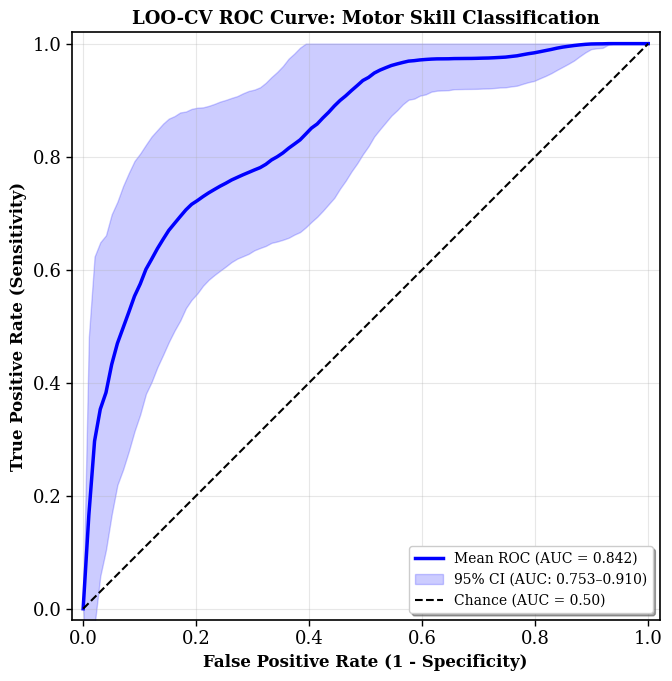

In [51]:
# ROC curve with confidence intervals using bootstrapping

# Bootstrap for confidence intervals
n_bootstraps = 1000
tprs = []
aucs = []
base_fpr = np.linspace(0, 1, 100)

# Set random seed for reproducibility
np.random.seed(42)
for i in range(n_bootstraps):
    # Resample with replacement
    indices = resample(range(len(y)), replace=True, random_state=i)
    if len(np.unique(y.iloc[indices])) < 2:
        # Skip if bootstrap sample has only one class
        continue
    
    # Get bootstrap sample
    y_boot = y.iloc[indices]
    y_prob_boot = y_prob[indices]
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_boot, y_prob_boot)
    
    # Interpolate to common FPR axis
    tpr_interp = np.interp(base_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    
    # Store AUC
    aucs.append(auc(fpr, tpr))

# Compute mean and confidence intervals for TPR at each FPR point
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
tpr_lower = mean_tpr - 1.96 * std_tpr

# Calculate AUC confidence interval
auc_mean = np.mean(aucs)
auc_ci_lower = np.percentile(aucs, 2.5)
auc_ci_upper = np.percentile(aucs, 97.5)

# Create plot
fig, ax = plt.subplots(figsize=(7, 7))

# Plot mean ROC curve
ax.plot(base_fpr, mean_tpr, 'b-', linewidth=2.5, 
        label=f'Mean ROC (AUC = {auc_mean:.3f})')

# Plot confidence interval
ax.fill_between(base_fpr, tpr_lower, tpr_upper, alpha=0.2, 
                color='blue', label=f'95% CI (AUC: {auc_ci_lower:.3f}–{auc_ci_upper:.3f})')

# Add chance line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Chance (AUC = 0.50)')

# Formatting
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('LOO-CV ROC Curve: Motor Skill Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect('equal')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('ML-Figures/roc_curve_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
# Feature Importance by Partner Type

# If using logistic regression, plot the coefficients. If using HGBC, we have already printed the permutation importance results above.
if logReg:

    # Prepare data
    pipe.fit(X, y)
    coefs = pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coef': coefs
    })

    # Parse features
    def parse_feature(feat):
        parts = feat.split('_')
        return {
            'block': parts[0],
            'task': parts[1], 
            'partner': 'Metronome' if 'Met' in feat else 'Experimenter'
        }

    # Add parsed columns
    coef_df['parsed'] = coef_df['feature'].apply(parse_feature)
    coef_df['block'] = coef_df['parsed'].apply(lambda x: x['block'])
    coef_df['task'] = coef_df['parsed'].apply(lambda x: x['task'])
    coef_df['partner'] = coef_df['parsed'].apply(lambda x: x['partner'])

    # Split by partner type
    met_df = coef_df[coef_df['partner'] == 'Metronome'].sort_values('coef').reset_index(drop=True)
    exp_df = coef_df[coef_df['partner'] == 'Experimenter'].sort_values('coef').reset_index(drop=True)

    # Create side-by-side plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

    # === LEFT PANEL: Metronome ===
    colors_met = ['#d62728' if c > 0 else '#1f77b4' for c in met_df['coef']]
    bars_met = ax1.barh(range(len(met_df)), met_df['coef'], color=colors_met, 
                        alpha=0.7, edgecolor='black', linewidth=0.8)

    # Set y-ticks and labels
    labels_met = [f"{row['block']}_{row['task']}" for _, row in met_df.iterrows()]
    ax1.set_yticks(range(len(met_df)))
    ax1.set_yticklabels(labels_met, fontsize=10)
    ax1.axvline(x=0, color='black', linewidth=2)
    ax1.set_xlabel('Log-odds Coefficient', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Feature (Block × Task)', fontsize=12, fontweight='bold')
    ax1.set_title('Participant ↔ Metronome', fontsize=13, fontweight='bold', pad=10)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')

    # === RIGHT PANEL: Experimenter ===
    colors_exp = ['#d62728' if c > 0 else '#1f77b4' for c in exp_df['coef']]
    bars_exp = ax2.barh(range(len(exp_df)), exp_df['coef'], color=colors_exp, 
                        alpha=0.7, edgecolor='black', linewidth=0.8)

    # Set y-ticks and labels
    labels_exp = [f"{row['block']}_{row['task']}" for _, row in exp_df.iterrows()]
    ax2.set_yticks(range(len(exp_df)))
    ax2.set_yticklabels(labels_exp, fontsize=10)
    ax2.axvline(x=0, color='black', linewidth=2)
    ax2.set_xlabel('Log-odds Coefficient', fontsize=12, fontweight='bold')
    ax2.set_ylabel('')
    ax2.set_title('Participant ↔ Experimenter', fontsize=13, fontweight='bold', pad=10)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    # Overall title and legend
    fig.suptitle('Feature Importance by Partner Type (Predicting Motor Skill Classification)', 
                fontsize=14, fontweight='bold', y=0.98)

    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.7, edgecolor='black', 
            label='← Predicts Green'),
        Patch(facecolor='#d62728', alpha=0.7, edgecolor='black',
            label='Predicts Amber/Red →')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, 
            fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.93))

    # Adjust layout and save figure
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig('ML-Figures/coefficient_plot_by_partner.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("\nPlot not available for HGBC. Permutation importance (HGBC) already printed above.")


Plot not available for HGBC. Permutation importance (HGBC) already printed above.


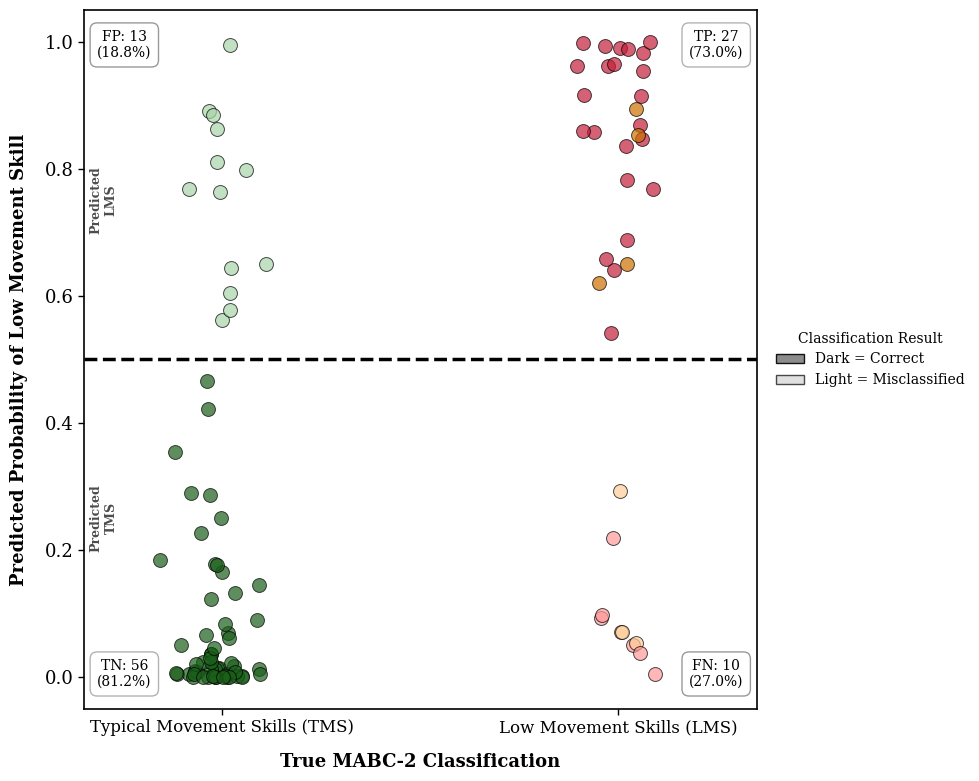

In [53]:
# Individual Predictions Scatter Plot

# Collate predictions back onto model_df to prepare for plotting
#results_df = model_df[["ppt", "child_age_years", "neurotype",  "con_adhd_index_raw", "aq_total", "data_alignment", "data_violations", "mabc_interpretation", "mabc_binary"]].copy()
results_df = model_df[["ppt", "child_age_years", "neurotype", "data_alignment", "data_violations", "mabc_interpretation", "mabc_binary"]].copy()
results_df["y_prob"] = y_prob
results_df["y_pred"] = y_pred

# Map binary predictions and true labels to text for better interpretability in the plot
results_df["pred_label"] = results_df["y_pred"].map({0: "Green", 1: "Amber/Red"})
results_df["true_label"] = results_df["mabc_binary"].map({0: "Green", 1: "Amber/Red"})

# Define error types for color coding
results_df["error_type"] = np.where(
    results_df["y_pred"] == results_df["mabc_binary"],
    "Correct",
    np.where(results_df["mabc_binary"] == 1, "Amber/Red→Green (FN)", "Green→Amber/Red (FP)")
)

# Add jitter for visibility
np.random.seed(42)
results_df['jitter_x'] = results_df['true_label'].map({'Green': 0, 'Amber/Red': 1}) + \
                         np.random.normal(0, 0.06, len(results_df))

# Create color mapping: true classification (including Amber vs Red) + correction status
# Dark colors for correct, light colors for incorrect
color_map = {
    ('Green', 'Correct'): '#1a5f1a',                    # Dark green
    ('Green', 'Green→Amber/Red (FP)'): '#a8d5a8',       # Light green
    ('Amber', 'Correct'): '#cc7000',                    # Dark amber/orange
    ('Amber', 'Amber/Red→Green (FN)'): '#ffcc99',       # Light amber/orange
    ('Red', 'Correct'): '#c41e3a',                      # Dark red
    ('Red', 'Amber/Red→Green (FN)'): '#ff9999'          # Light red
}

# Assign colors based on MABC interpretation and error type
results_df['point_color'] = results_df.apply(
    lambda row: color_map[(row['mabc_interpretation'], row['error_type'])], 
    axis=1
)

# Create figure with narrower width to bring categories closer
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all points with their assigned colors
for idx, row in results_df.iterrows():
    ax.scatter(row['jitter_x'], row['y_prob'], 
               color=row['point_color'], s=100, alpha=0.7, 
               edgecolors='black', linewidth=0.7, zorder=3)

# Plot decision threshold
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2.5, 
           label='Decision Threshold (0.5)', zorder=2)

# Calculate sample sizes for percentage calculations
green_n = len(results_df[results_df['true_label'] == 'Green'])
amber_n = len(results_df[results_df['true_label'] == 'Amber/Red'])

# Calculate counts for all four categories
tn_count = len(results_df[(results_df['true_label'] == 'Green') & (results_df['error_type'] == 'Correct')])
fp_count = len(results_df[(results_df['true_label'] == 'Green') & (results_df['error_type'] == 'Green→Amber/Red (FP)')])
fn_count = len(results_df[(results_df['true_label'] == 'Amber/Red') & (results_df['error_type'] == 'Amber/Red→Green (FN)')])
tp_count = len(results_df[(results_df['true_label'] == 'Amber/Red') & (results_df['error_type'] == 'Correct')])

# Add boxes with counts and percentages for each category
# True Negatives box (bottom left)
ax.text(0.06, 0.05, f'TN: {tn_count}\n({tn_count/green_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.3, edgecolor='black', linewidth=1))

# False Positives box (top left)
ax.text(0.06, 0.95, f'FP: {fp_count}\n({fp_count/green_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.4, edgecolor='black', linewidth=1))

# True Positives box (top right)
ax.text(0.94, 0.95, f'TP: {tp_count}\n({tp_count/amber_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.3, edgecolor='black', linewidth=1))

# False Negatives box (bottom right)
ax.text(0.94, 0.05, f'FN: {fn_count}\n({fn_count/amber_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.4, edgecolor='black', linewidth=1))

# Formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Typical Movement Skills (TMS)', 'Low Movement Skills (LMS)'], 
                   fontsize=12, fontweight='normal')
ax.set_ylabel('Predicted Probability of Low Movement Skill', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xlabel('True MABC-2 Classification', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-0.35, 1.35)
# ax.set_title('Model Predictions vs. True Classifications', 
#             fontsize=14, fontweight='bold', pad=25)

# Add zone labels
ax.text(-0.30, 0.25, 'Predicted\nTMS', fontsize=9, ha='center', 
        va='center', color='black', fontweight='bold', alpha=0.7, 
        rotation=90)
ax.text(-0.30, 0.75, 'Predicted\nLMS', fontsize=9, ha='center', 
        va='center', color='black', fontweight='bold', alpha=0.7,
        rotation=90)

# Simplified legend showing just the pattern
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', edgecolor='black', alpha=0.9,
          label='Dark = Correct'),
    Patch(facecolor='lightgray', edgecolor='black', alpha=0.7,
          label='Light = Misclassified')
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.01, 0.5), 
          fontsize=10, frameon=False, 
          title='Classification Result', title_fontsize=10)

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('ML-Figures/prediction_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
